In [40]:
import json
import baltic as bt
from collections import defaultdict
import scipy.stats as stats
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib as mpl

In [41]:

with open(f'hosts/h3nx/traits.json') as f:
    traits = json.load(f)

node_traits = traits["nodes"]
    

In [42]:
node_traits

{'TS_NODE_6102': {'host': 'Avian',
  'host_confidence': {'Avian': 0.9761079783263151,
   'Equine': 0.013620412784829606,
   'Swine': 0.00645002421992345,
   'Seal': 0.0014402636685716542},
  'host_entropy': 0.14209825410877103,
  'country': 'Canada',
  'country_confidence': {'Canada': 0.13604736652890242,
   'Chile': 0.04376259544945536,
   'Usa': 0.03659100849425018,
   'Japan': 0.013276862972706643,
   'Nigeria': 0.01104324509642628,
   'Bangladesh': 0.010761475154673558,
   'Philippines': 0.01052422018003183,
   'Laos': 0.010486717757338419,
   'India': 0.010485465620359069,
   'Bhutan': 0.010482916891064554,
   'El Salvador': 0.010473967445823228,
   'Romania': 0.010463752548613411,
   'Jordan': 0.01046271760750412,
   'Egypt': 0.010449967659654443,
   'Zambia': 0.010442910325769054,
   'Israel': 0.010429746061688788,
   'Hungary': 0.010428464848654808,
   'Qatar': 0.010420600117234604,
   'Iran': 0.01039439990616165,
   'Luxembourg': 0.010390903501990513,
   'Poland': 0.0103905864

In [ ]:

# reassortments were randomized and stored in 'h3nx/trees'
# counting up how many host switched occur on null reassorted internal nodes, and on those reassorted nodes, what is the host switch

results = {}

for i in range(1000):
        
    tree = f'hosts/h3nx/trees/randomized_tree_{i}.nwk'
    mytree = bt.loadNewick(tree, absoluteTime=False)
    
    host_switch_rea = no_switch_rea = 0
    host_switch_clonal = no_switch_clonal = 0
    
    host_switches = defaultdict(int)

    for k in mytree.Objects:
        
        if k.is_node() and k.parent.traits != {}:
            
            parent_host = node_traits[k.parent.traits["label"]]["host"] 
            k_host = node_traits[k.traits["label"]]["host"]
            
            if k.traits['is_reassorted']:

                if parent_host == k_host:
                    no_switch_rea += 1
                else:
                    host_switch_rea += 1
                    host_switches[(parent_host, k_host)] += 1

            else: 
                if parent_host == k_host:
                    no_switch_clonal += 1
                else:
                    host_switch_clonal += 1

    host_switches_json = {
        (parent, child): count
        for (parent, child), count in host_switches.items()
    }

    results[i] = {
        "host_switch_rea": host_switch_rea,
        "no_switch_rea": no_switch_rea,
        "host_switch_clonal": host_switch_clonal,
        "no_switch_clonal": no_switch_clonal,
        "host_switch_pairs": host_switches_json
    }

In [ ]:
# json doesnt let you make keys tuples which is annoying

for results in results.items():
    results_for_json = {}
    for clade, vals in results.items():
        new_vals = vals.copy()
        new_vals["host_switch_pairs"] = {f"{f}->{t}": c for (f, t), c in vals["host_switch_pairs"].items()}
        results_for_json[clade] = new_vals

# instead of having to rerun this code which takes 30 min to run, we just dump it into a json to access later
    with open(f"jsons/host_switch_counts_h3nx.json", "w") as f:
        json.dump(results_for_json, f, indent=2)


In [45]:
# accessing the randomized results described earlier

with open(f"jsons/host_switch_counts_h3nx.json") as file:
    data = json.load(file)

for clade, vals in data.items():
    host_switch_pairs = {}
    for key, count in vals["host_switch_pairs"].items():
        f, t = key.split("->")
        host_switch_pairs[(f.lower(), t.lower())] = count
    data[clade]["host_switch_pairs"] = host_switch_pairs

In [46]:
data

{'0': {'host_switch_rea': 3,
  'no_switch_rea': 830,
  'host_switch_clonal': 44,
  'no_switch_clonal': 5225,
  'host_switch_pairs': {('human', 'swine'): 3}},
 '1': {'host_switch_rea': 9,
  'no_switch_rea': 845,
  'host_switch_clonal': 38,
  'no_switch_clonal': 5210,
  'host_switch_pairs': {('equine', 'canine'): 1,
   ('avian', 'seal'): 1,
   ('human', 'swine'): 6,
   ('swine', 'human'): 1}},
 '2': {'host_switch_rea': 6,
  'no_switch_rea': 875,
  'host_switch_clonal': 41,
  'no_switch_clonal': 5180,
  'host_switch_pairs': {('avian', 'seal'): 1,
   ('feline', 'canine'): 1,
   ('avian', 'human'): 1,
   ('human', 'swine'): 3}},
 '3': {'host_switch_rea': 5,
  'no_switch_rea': 838,
  'host_switch_clonal': 42,
  'no_switch_clonal': 5217,
  'host_switch_pairs': {('human', 'swine'): 1, ('swine', 'avian'): 4}},
 '4': {'host_switch_rea': 5,
  'no_switch_rea': 840,
  'host_switch_clonal': 42,
  'no_switch_clonal': 5215,
  'host_switch_pairs': {('equine', 'canine'): 1,
   ('human', 'swine'): 3,
   

In [47]:
# from the actual data, generated in within-between_FET.ipynb in analyses/within-between_host/

real_data = {"p_value": 0.0000000934, 
                "OR": 5.49, 
                "host_switch_pairs": {
                        ('avian', 'mammal'): 2, 
                        ('mammal', 'mammal'): 18, 
                        ('mammal', 'avian'): 1 
                        }       
        }

In [48]:
alpha = 0.05

results = {}

significant_count = 0

for rep, vals in data.items():
        
    a = vals["host_switch_rea"]
    b = vals["no_switch_rea"]
    c = vals["host_switch_clonal"]
    d = vals["no_switch_clonal"]
    
    table = [[a, b], [c, d]]
    
    odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')
    
    # count significant p values
    if p_value < alpha:
        significant_count += 1
    

results = {
    'significant_count': significant_count
}

print(results)

{'significant_count': 32}


In [49]:
# across the 1000 randomized reassortment trees, how many times was each host switch pair annotated on a reassorted internal node
# taking the average

all_pairs = set()
for vals in data.values():
    all_pairs.update(vals["host_switch_pairs"].keys())

all_pairs_counts = {pair: [] for pair in all_pairs}

for vals in data.values():
    for pair in all_pairs:
        count = vals["host_switch_pairs"].get(pair, 0)  # 0 if pair missing in this clade
        all_pairs_counts[pair].append(count)

pair_stats = {}

for pair, counts in all_pairs_counts.items():
    counts_array = np.array(counts)
    mean_count = counts_array.mean()
    sd_count = counts_array.std(ddof=1)  # sample SD

    pair_stats[pair] = {"mean": mean_count, "sd": sd_count}


In [50]:
pair_stats

{('avian', 'equine'): {'mean': 0.157, 'sd': 0.3639828065767441},
 ('swine', 'human'): {'mean': 0.146, 'sd': 0.35328290194801215},
 ('equine', 'canine'): {'mean': 0.149, 'sd': 0.3562666500332664},
 ('swine', 'mink'): {'mean': 0.142, 'sd': 0.34922479573758497},
 ('avian', 'human'): {'mean': 0.136, 'sd': 0.3429600875052688},
 ('swine', 'avian'): {'mean': 1.107, 'sd': 0.9820975081505479},
 ('avian', 'canine'): {'mean': 0.155, 'sd': 0.36208577175319395},
 ('canine', 'feline'): {'mean': 0.139, 'sd': 0.3461196307619648},
 ('avian', 'swine'): {'mean': 0.286, 'sd': 0.49035134795822105},
 ('human', 'swine'): {'mean': 3.753, 'sd': 1.7694977033390356},
 ('avian', 'seal'): {'mean': 0.131, 'sd': 0.33756918246924283},
 ('feline', 'canine'): {'mean': 0.146, 'sd': 0.35328290194801215},
 ('equine', 'swine'): {'mean': 0.127, 'sd': 0.33313958333104454}}

In [51]:
simplified_counts_per_clade = []

for vals in data.values():
    host_switches = vals["host_switch_pairs"]
    simplified = {}

    print(vals)

    for (from_host, to_host), count in host_switches.items():
        from_label = from_host if from_host == "avian" else "mammal"
        to_label = to_host if to_host == "avian" else "mammal"
        key = (from_label, to_label)
        simplified[key] = simplified.get(key, 0) + count

    for key in [("avian","mammal"), ("mammal","avian"), ("mammal","mammal")]:
        simplified.setdefault(key, 0)

    simplified_counts_per_clade.append(simplified)

simplified_agg = {key: [] for key in [("avian","mammal"), ("mammal","avian"), ("mammal","mammal")]}

for simplified in simplified_counts_per_clade:
    for key, count in simplified.items():
        simplified_agg[key].append(count)


{'host_switch_rea': 3, 'no_switch_rea': 830, 'host_switch_clonal': 44, 'no_switch_clonal': 5225, 'host_switch_pairs': {('human', 'swine'): 3}}
{'host_switch_rea': 9, 'no_switch_rea': 845, 'host_switch_clonal': 38, 'no_switch_clonal': 5210, 'host_switch_pairs': {('equine', 'canine'): 1, ('avian', 'seal'): 1, ('human', 'swine'): 6, ('swine', 'human'): 1}}
{'host_switch_rea': 6, 'no_switch_rea': 875, 'host_switch_clonal': 41, 'no_switch_clonal': 5180, 'host_switch_pairs': {('avian', 'seal'): 1, ('feline', 'canine'): 1, ('avian', 'human'): 1, ('human', 'swine'): 3}}
{'host_switch_rea': 5, 'no_switch_rea': 838, 'host_switch_clonal': 42, 'no_switch_clonal': 5217, 'host_switch_pairs': {('human', 'swine'): 1, ('swine', 'avian'): 4}}
{'host_switch_rea': 5, 'no_switch_rea': 840, 'host_switch_clonal': 42, 'no_switch_clonal': 5215, 'host_switch_pairs': {('equine', 'canine'): 1, ('human', 'swine'): 3, ('swine', 'avian'): 1}}
{'host_switch_rea': 3, 'no_switch_rea': 840, 'host_switch_clonal': 44, 'no

In [52]:
for key, counts in simplified_agg.items():
    print(f"\n{key}:")
    count_freq = Counter(counts)
    for value, frequency in sorted(count_freq.items()):
        print(f"  {value}: appears {frequency} times")


('avian', 'mammal'):
  0: appears 376 times
  1: appears 423 times
  2: appears 167 times
  3: appears 29 times
  4: appears 4 times
  5: appears 1 times

('mammal', 'avian'):
  0: appears 301 times
  1: appears 401 times
  2: appears 209 times
  3: appears 70 times
  4: appears 17 times
  5: appears 2 times

('mammal', 'mammal'):
  0: appears 8 times
  1: appears 39 times
  2: appears 84 times
  3: appears 161 times
  4: appears 230 times
  5: appears 178 times
  6: appears 138 times
  7: appears 76 times
  8: appears 48 times
  9: appears 26 times
  10: appears 9 times
  11: appears 2 times
  12: appears 1 times


In [53]:

p_values = {}

for key, null_vals in simplified_agg.items():

    null_vals = np.array(null_vals)
    obs = real_data["host_switch_pairs"].get(key, 0)

    mu = null_vals.mean()

    extreme = np.sum(np.abs(null_vals - mu) >= abs(obs - mu))
    p = (extreme + 1) / (len(null_vals) + 1)

    p_values[key] = 1.0 if p > 1 else p


In [54]:
p_values

{('avian', 'mammal'): 0.2017982017982018,
 ('mammal', 'avian'): 1.0,
 ('mammal', 'mammal'): 0.000999000999000999}

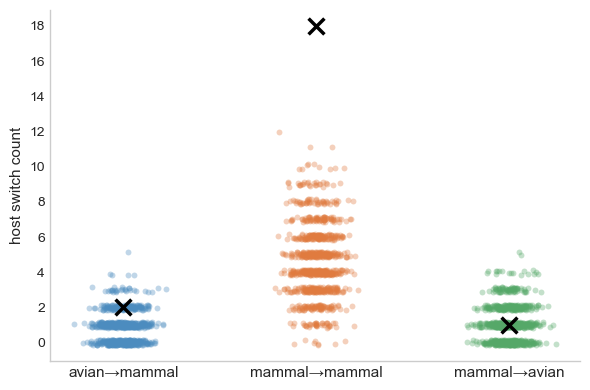

In [55]:


keys = [("avian","mammal"), ("mammal","mammal"), ("mammal","avian")]
colors = ["#4C8CBF", "#E07B3F", "#55A868"]  # muted blue, orange, green

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(6, 4))

rng = np.random.default_rng(42)

for i, (key, color) in enumerate(zip(keys, colors)):
    null_vals = np.array(simplified_agg[key])
    obs = real_data["host_switch_pairs"].get(key, 0)

    # jitter both axes slightly to break up integer banding
    x = rng.normal(i, 0.07, size=len(null_vals))
    y = null_vals + rng.uniform(-0.15, 0.15, size=len(null_vals))

    ax.scatter(x, y, alpha=0.35, s=18, color=color, linewidths=0)

    ax.scatter(i, obs, marker="x", color="black", s=130, linewidth=2.5, zorder=5)

ax.set_xticks(range(len(keys)))
ax.set_xticklabels([f"{k[0]}→{k[1]}" for k in keys], fontsize=11)
ax.set_ylabel("host switch count", fontsize=11)
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

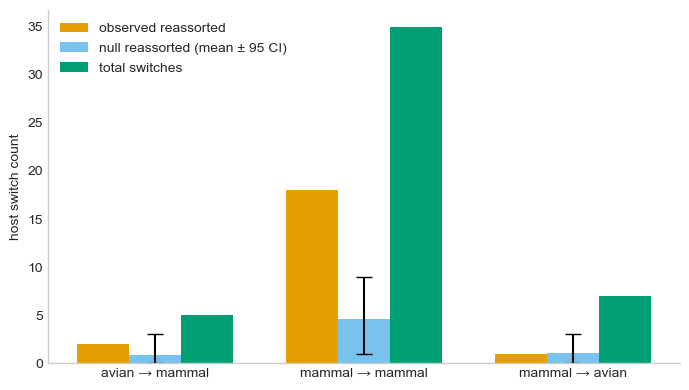

In [56]:
total_switches = {
    ('avian', 'mammal'): 5,
    ('mammal', 'mammal'): 35,
    ('mammal', 'avian'): 7
}

categories = [
    ('avian', 'mammal'),
    ('mammal', 'mammal'),
    ('mammal', 'avian')
]

labels = [
    "avian → mammal",
    "mammal → mammal",
    "mammal → avian"
]

real_vals = [real_data["host_switch_pairs"][c] for c in categories]
total_vals = [total_switches[c] for c in categories]

real_vals = [real_data["host_switch_pairs"][c] for c in categories]

null_low = [np.percentile(simplified_agg[c], 2.5) for c in categories]
null_high = [np.percentile(simplified_agg[c], 97.5) for c in categories]

null_means = [np.mean(simplified_agg[c]) for c in categories]

yerr = [
    np.array(null_means) - np.array(null_low),
    np.array(null_high) - np.array(null_means)
]

x = np.arange(len(categories))
width = 0.25  # narrow to fit 3 bars per category

observed_color = "#E69F00"   # orange
null_color = "#56B4E9"       # blue
total_color = "#009E73"      # green

fig, ax = plt.subplots(figsize=(7,4))

ax.bar(
    x - width,
    real_vals,
    width,
    label="observed reassorted",
    color=observed_color
)

ax.bar(
    x,
    null_means,
    width,
    yerr=yerr,
    capsize=6,
    label="null reassorted (mean ± 95 CI)",
    color=null_color,
    alpha=0.8
)

ax.bar(
    x + width,
    total_vals,
    width,
    label="total switches",
    color=total_color
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("host switch count")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.legend(frameon=False)
plt.savefig(f"obs_vs_null_switches_total.pdf", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

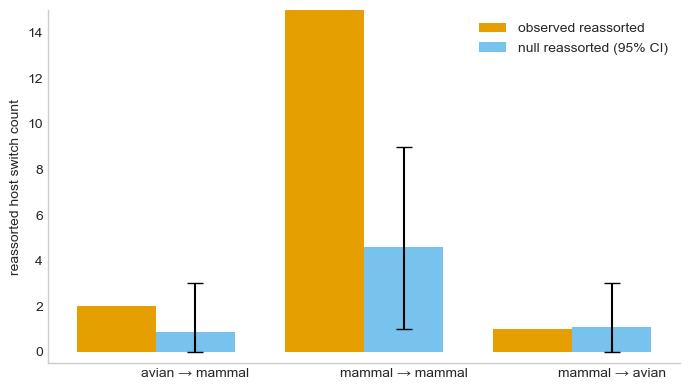

In [57]:
categories = [
    ('avian', 'mammal'),
    ('mammal', 'mammal'),
    ('mammal', 'avian')
]

labels = [
    "avian → mammal",
    "mammal → mammal",
    "mammal → avian"
]

real_vals = [real_data["host_switch_pairs"][c] for c in categories]

null_low = [np.percentile(simplified_agg[c], 2.5) for c in categories]
null_high = [np.percentile(simplified_agg[c], 97.5) for c in categories]

null_means = [np.mean(simplified_agg[c]) for c in categories]

yerr = [
    np.array(null_means) - np.array(null_low),
    np.array(null_high) - np.array(null_means)
]

x = np.arange(len(categories))
width = 0.38  # narrow to fit 3 bars per category

observed_color = "#E69F00"   # orange
null_color = "#56B4E9"       # blue

fig, ax = plt.subplots(figsize=(7,4))

ax.bar(
    x - width,
    real_vals,
    width,
    label="observed reassorted",
    color=observed_color
)

ax.bar(
    x,
    null_means,
    width,
    yerr=yerr,
    capsize=6,
    label="null reassorted (95% CI)",
    color=null_color,
    alpha=0.8
)


ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("reassorted host switch count")
ax.set_ylim(-0.5, 15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.legend(frameon=False)
plt.savefig(f"obs_vs_null_switches.pdf", dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()